In [5]:
!pip install imblearn

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler 

In [7]:
# load the dataset
df = pd.read_csv("pop_unclean_dataset.csv",encoding='utf-8')

#loading first five rows
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG


In [8]:
x = df.iloc[:,0:5]

In [9]:
x

,country,continent,year,lifeExp,pop
0,Afghanistan,Asia,1952,28.801,8425333
1,Afghanistan,Asia,1957,30.332,9240934
2,Afghanistan,Asia,1962,31.997,10267083
3,Afghanistan,Asia,1967,34.020,11537966
4,Afghanistan,Asia,1972,36.088,13079460
...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418
1700,Zimbabwe,Africa,1992,60.377,10704340
1701,Zimbabwe,Africa,1997,46.809,11404948
1702,Zimbabwe,Africa,2002,39.989,11926563


In [10]:
y = df['iso_alpha']

In [11]:
ok = RandomOverSampler()

In [12]:
x_sample,y_sample = ok.fit_resample(x,y)

In [13]:
y_sample.value_counts()

iso_alpha
AFG    24
ALB    24
DZA    24
AGO    24
ARG    24
       ..
VNM    24
PSE    24
YEM    24
ZMB    24
ZWE    24
Name: count, Length: 141, dtype: int64

C:\Users\anchita\AppData\Local\Temp\ipykernel_4680\2989476183.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['gdpPercap'])


<Axes: xlabel='gdpPercap', ylabel='Density'>

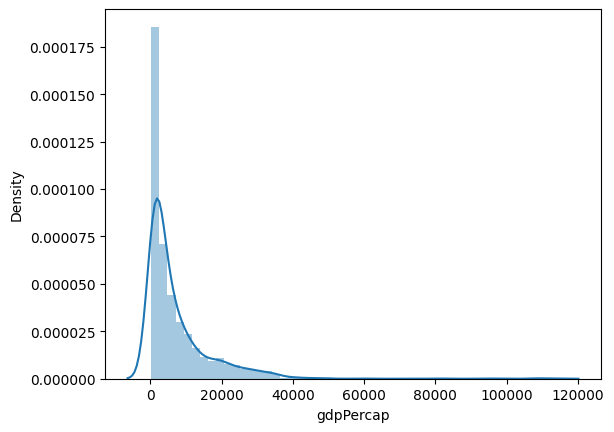

In [14]:
sns.distplot(df['gdpPercap'])

<Axes: ylabel='gdpPercap'>

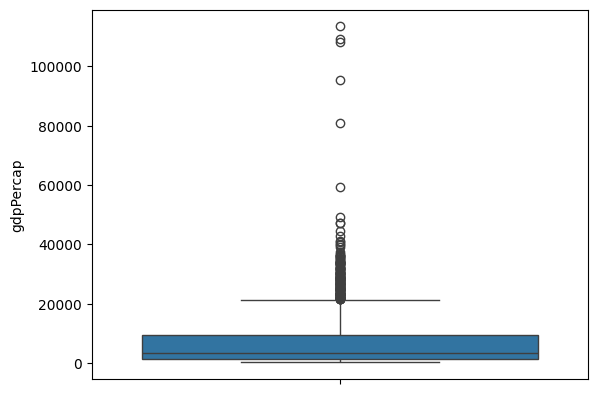

In [15]:
sns.boxplot(df['gdpPercap'])

In [16]:
Q1 = df["gdpPercap"].quantile(0.25)
Q3 = df["gdpPercap"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[df["gdpPercap"].between(lower_bound, upper_bound)]


# Print the outlier bounds
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df[(df["lifeExp"] < lower_bound) | (df["lifeExp"] > upper_bound)]

# Print the number of outliers and the outlier values
print(f"Number of outliers: {len(outliers)}")
print("Outlier values:")
print(outliers)

Lower bound: -10974.45715725
Upper bound: 21495.87994875
Number of outliers: 0
Outlier values:
Empty DataFrame
Columns: [country, continent, year, lifeExp, pop, gdpPercap, iso_alpha]
Index: []


<Axes: ylabel='gdpPercap'>

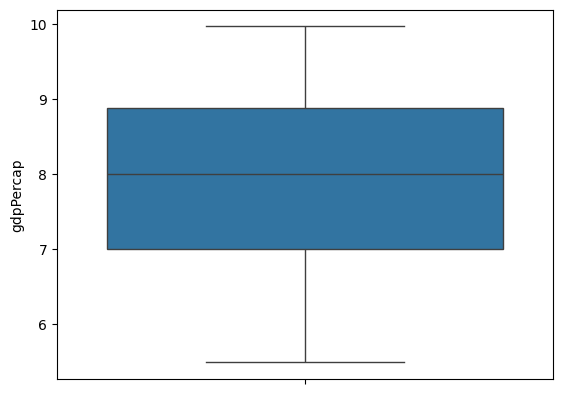

In [17]:
sns.boxplot(np.log(df['gdpPercap']))

C:\Users\anchita\AppData\Local\Temp\ipykernel_4680\3713881240.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['gdpPercap']))


<Axes: xlabel='gdpPercap', ylabel='Density'>

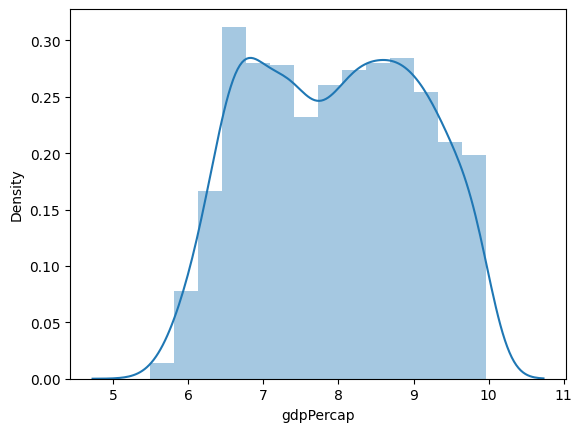

In [18]:
sns.distplot(np.log(df['gdpPercap']))

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139],
 [Text(0, 0, 'AFG'),
  Text(1, 0, 'ALB'),
  Text(2, 0, 'DZA'),
  Text(3, 0, 'AGO'),
  Text(4, 0, 'ARG'),
  Text(5, 0, 'AUS'),
  T

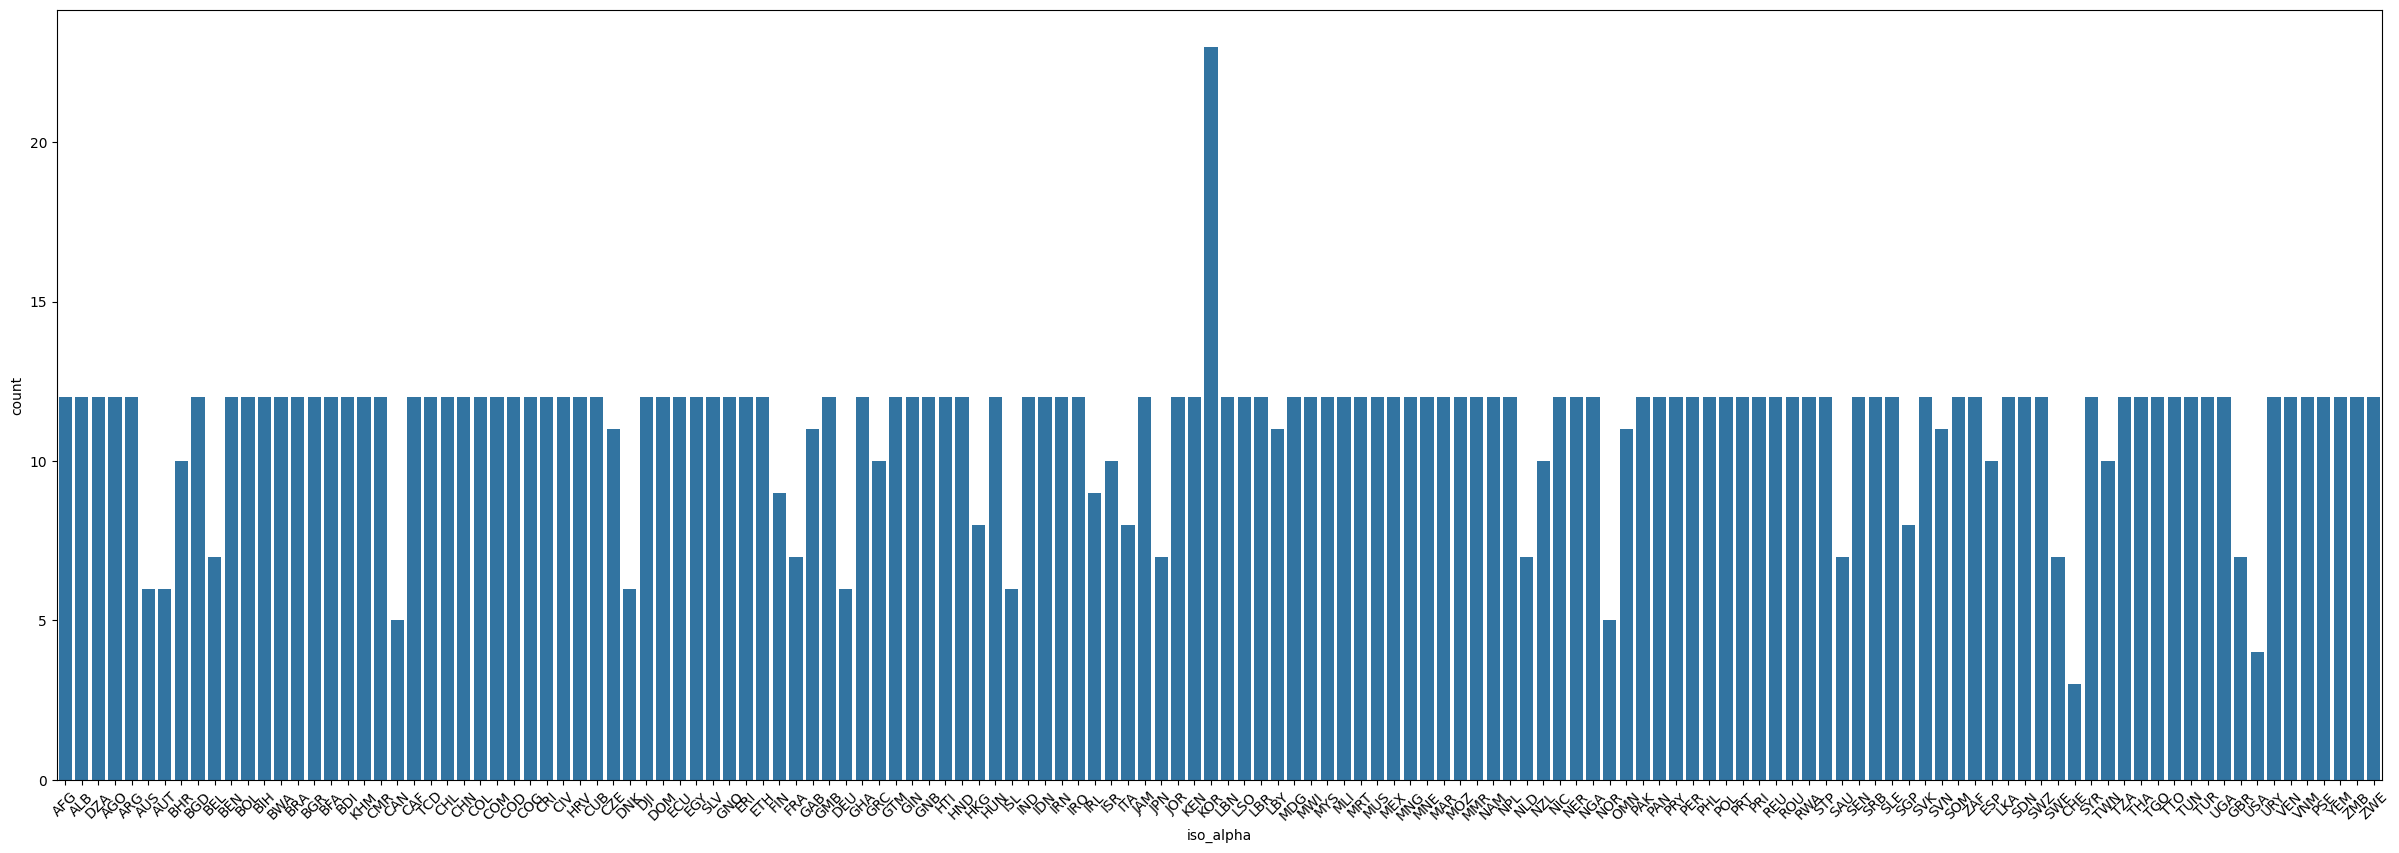

In [19]:
# Check Unbalanced Dataset
f = plt.figure()
f.set_figwidth(30)
f.set_figheight(10)
sns.countplot(x = 'iso_alpha',data=df)
plt.xticks(rotation=45)

In [20]:
df['iso_alpha'].value_counts()

iso_alpha
KOR    23
AFG    12
DZA    12
ALB    12
ARG    12
       ..
ISL     6
CAN     5
NOR     5
USA     4
CHE     3
Name: count, Length: 140, dtype: int64

In [21]:
sns.barplot(x ='sex', y ='total_bill', data = df, palette ='plasma') 

ValueError: Could not interpret value `sex` for `x`. An entry with this name does not appear in `data`.

In [ ]:
# doing undersampling 

# Separate features and target
X = df.drop('iso_alpha', axis=1)  # Drop the target column from the features
y = df['iso_alpha']

# Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)  # Ensure reproducibility

# Apply Random Undersampling
X_resampled, y_resampled = rus.fit_resample(X, y)

# Check the new class distribution
print(y_resampled.value_counts())

In [ ]:
# give statistical summary about the data
df.describe()

In [ ]:
#give info about each of the columns of the data
df.info()

In [ ]:
# check any null values in the dataset
print(df.isnull().sum())

In [ ]:
#Drop rows with missing values and place it in a new variable "df_cleaned"
df.dropna(inplace = True) # removes rows from columns that have null values, modifies original df

# Calculate the mean for numerical columns only
means = df.mean(numeric_only=True)

# Fill missing values in numerical columns with their respective means
# we do this to preserve the size of the dataset
df.fillna(value=means, inplace=True)

In [ ]:
# checking for duplicate records and removing them

#Identify duplicates
print(df.duplicated().sum())

#Remove duplicates
df_no_duplicates = df.drop_duplicates()

In [ ]:
# when a machine learning algorithm is used, it cannot process cateogorical data
# so we can convert it to numerical (binary) form in a way so that the system does not 
# perform numerical operations on it. For this we use the dummies function.

df_encoded = pd.get_dummies(df, columns=["country", "continent", "iso_alpha"])


In [ ]:
# IQR -- Interquartile range helps in recognizing outliers which is an important 
# aspect of data processing. We will perform this on each numerical column

Q1 = df["year"].quantile(0.25)
Q3 = df["year"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[df["year"].between(lower_bound, upper_bound)]


# Print the outlier bounds
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df[(df["year"] < lower_bound) | (df["year"] > upper_bound)]

# Print the number of outliers and the outlier values
print(f"Number of outliers: {len(outliers)}")
print("Outlier values:")
print(outliers)

In [ ]:
Q1 = df["lifeExp"].quantile(0.25)
Q3 = df["lifeExp"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[df["lifeExp"].between(lower_bound, upper_bound)]


# Print the outlier bounds
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df[(df["lifeExp"] < lower_bound) | (df["lifeExp"] > upper_bound)]

# Print the number of outliers and the outlier values
print(f"Number of outliers: {len(outliers)}")
print("Outlier values:")
print(outliers)

In [ ]:
Q1 = df["pop"].quantile(0.25)
Q3 = df["pop"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[df["pop"].between(lower_bound, upper_bound)]


# Print the outlier bounds
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df[(df["pop"] < lower_bound) | (df["pop"] > upper_bound)]

# Print the number of outliers and the outlier values
print(f"Number of outliers: {len(outliers)}")
print("Outlier values:")
print(outliers)

In [ ]:
Q1 = df["gdpPercap"].quantile(0.25)
Q3 = df["gdpPercap"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[df["gdpPercap"].between(lower_bound, upper_bound)]

# Print the outlier bounds
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df[(df["gdpPercap"] < lower_bound) | (df["gdpPercap"] > upper_bound)]

# Print the number of outliers and the outlier values
print(f"Number of outliers: {len(outliers)}")
print("Outlier values:")
print(outliers)